# Ejercicios prácticos: Introducción a Python y visualización gráfica

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [18]:
np.random.seed(42)
df_ventas = pd.DataFrame({
    'fecha': pd.date_range(start='2023-01-01', periods=100, freq='D'),
    'producto': np.random.choice(['A', 'B', 'C', 'D'], size=100),
    'vendedor': np.random.choice(['Juan', 'María', 'Pedro', 'Ana'], size=100),
    'unidades': np.random.randint(1, 50, size=100),
    'precio_unitario': np.random.uniform(10, 100, size=100).round(2),
    'región': np.random.choice(['Norte', 'Sur', 'Este', 'Oeste'], size=100)
})
df_ventas['total_venta'] = df_ventas['unidades'] * df_ventas['precio_unitario']
df_ventas['día_semana'] = df_ventas['fecha'].dt.day_name()
df_ventas

,fecha,producto,vendedor,unidades,precio_unitario,región,total_venta,día_semana
0,2023-01-01,C,Pedro,32,11.49,Este,367.68,Sunday
1,2023-01-02,D,María,39,56.09,Sur,2187.51,Monday
2,2023-01-03,A,María,49,30.38,Norte,1488.62,Tuesday
3,2023-01-04,C,Ana,32,68.07,Oeste,2178.24,Wednesday
4,2023-01-05,C,María,4,25.69,Norte,102.76,Thursday
...,...,...,...,...,...,...,...,...
95,2023-04-06,B,María,16,72.73,Este,1163.68,Thursday
96,2023-04-07,B,María,29,73.22,Sur,2123.38,Friday
97,2023-04-08,D,Ana,3,42.35,Oeste,127.05,Saturday
98,2023-04-09,B,Juan,20,36.42,Sur,728.40,Sunday


Análisis de Ventas
------------------------------
1. Encuentra el vendedor con más ventas totales
2. Calcula el promedio de ventas por día de la semana
3. Identifica el producto más vendido por región
4. Crea un gráfico que muestre la evolución de ventas por vendedor

### Solución 1: Vendedor con más ventas

In [19]:
mejor_vendedor = df_ventas.groupby('vendedor')['total_venta'].sum().sort_values(ascending=False)
print("Vendedor com más ventas totales:", mejor_vendedor.index[0], mejor_vendedor.iloc[0])

Vendedor com más ventas totales: Pedro 44451.45


### Solución 2: Promedio de ventas por día

In [20]:
ventas_por_dia = df_ventas.groupby('día_semana')['total_venta'].mean()
print("Promedio de ventas por día:")
print(ventas_por_dia)

Promedio de ventas por día:
día_semana
Friday       1745.609286
Monday       1766.608667
Saturday     2171.896429
Sunday       1467.956000
Thursday     1866.805000
Tuesday       873.612143
Wednesday     672.854286
Name: total_venta, dtype: float64


### Solución 3: Producto más vendido por región

In [21]:
producto_region = df_ventas.groupby(['región', 'producto'])['unidades'].sum().unstack()
mejor_producto_region = producto_region.idxmax(axis=1)
print("Producto más vendido por región:")
print(mejor_producto_region)

Producto más vendido por región:
región
Este     D
Norte    C
Oeste    B
Sur      D
dtype: object


### Solución 4: Gráfico de evolución de ventas por vendedor

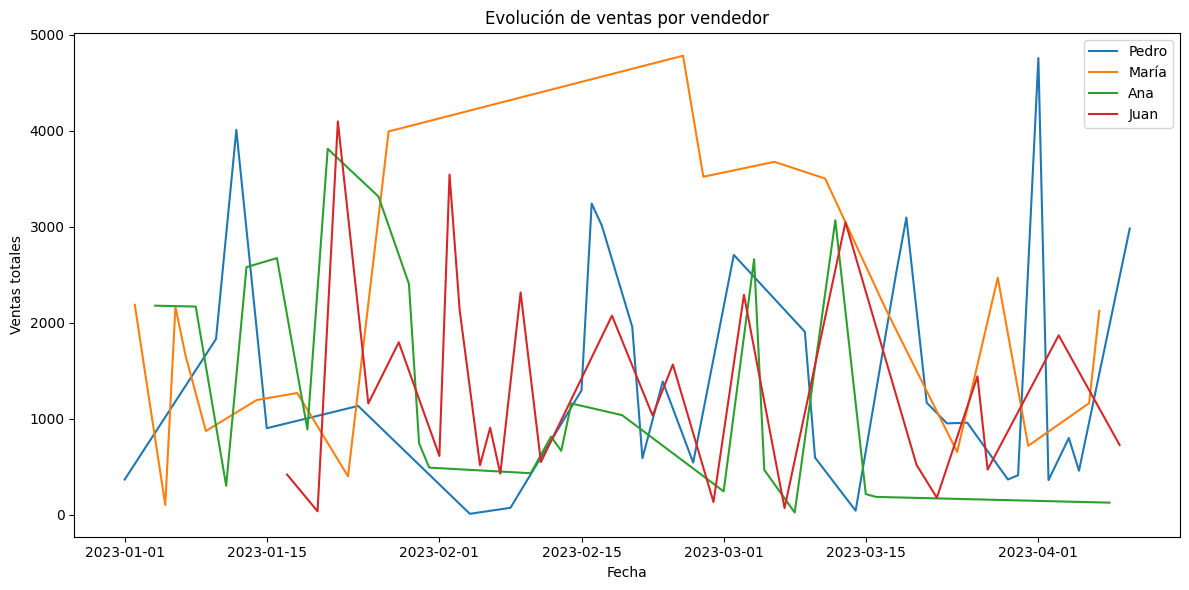

In [22]:
plt.figure(figsize=(12, 6))
for vendedor in df_ventas['vendedor'].unique():
    ventas_vendedor = df_ventas[df_ventas['vendedor'] == vendedor].groupby('fecha')['total_venta'].sum()
    plt.plot(ventas_vendedor.index, ventas_vendedor.values, label=vendedor)
plt.title('Evolución de ventas por vendedor')
plt.xlabel('Fecha')
plt.ylabel('Ventas totales')
plt.legend()
plt.tight_layout()
plt.show()